# **Customer Segmentation Analysis**

In [1]:
# Import Library 

import pandas as pd

# Import Dataset

In [2]:
# Online_Retail_Dataset

df = pd.read_csv('Online Retail_Task2.csv')

In [3]:
# Overview of Dataset

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


# Inspect Dataset

In [4]:
# Shape of the Dataset

df.shape

(541909, 8)

In [5]:
# Columns Datatype

df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [6]:
# Description of dataset

df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

             InvoiceDate  UnitPrice  Cust

In [7]:
# Dataset info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Data Cleaning

In [8]:
# Check Null values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# Check Duplicate value

df.duplicated().sum()

np.int64(5268)

In [10]:
# Removing Duplicate values

df = df.drop_duplicates()
print('Shape after removing duplicate:', df.shape)

Shape after removing duplicate: (536641, 8)


## Data Cleaning – Removing Duplicate Records

The dataset initially contained 5,268 duplicate transaction records. These duplicate records were removed to prevent repeated transactions from affecting customer purchase frequency and monetary calculations during the RFM analysis.

# Handling Missing Values

In [11]:
# Handle Missing Customer IDs

df = df.dropna(subset = ['CustomerID'])

print("Shape after removing missing Customer IDs:", df.shape)
print("Missing Customer IDs:", df['CustomerID'].isnull().sum())

Shape after removing missing Customer IDs: (401604, 8)
Missing Customer IDs: 0


## Handling Missing Customer IDs
CustomerID is essential for customer segmentation because RFM metrics need to be calculated at the individual customer level. Therefore, transactions with missing CustomerID values were removed from the analysis.

In [12]:
# Convert InvoiceDate into Datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format = '%d-%m-%Y %H:%M')

# Convert CustomerID into Integer
df['CustomerID'] = df['CustomerID'].astype(int)

In [13]:
# Check Negative Quantity 

print("Minimum Quantity:", df['Quantity'].min())
print("Negative Quantity:", (df['Quantity'] < 0).sum())

Minimum Quantity: -80995
Negative Quantity: 8872


In [14]:
# Check Negative UnitPrice

print("Minimum UnitPrice:", df['UnitPrice'].min())
print("Zero/Negative UnitPrice:", (df['UnitPrice'] <= 0).sum())

Minimum UnitPrice: 0.0
Zero/Negative UnitPrice: 40


In [15]:
# Check Cancelled InvoiceNo

cancelled = df['InvoiceNo'].astype(str).str.startswith('C').sum()
print("Cancelled Invoices:", cancelled)

Cancelled Invoices: 8872


In [16]:
# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove non-positive Quantity and Unitprice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (392692, 8)


In [17]:
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Zero/Negative UnitPrice:", (df['UnitPrice'] <= 0).sum())
print("Cancelled Invoices:",
      df['InvoiceNo'].astype(str).str.startswith('C').sum())

Negative Quantity: 0
Zero/Negative UnitPrice: 0
Cancelled Invoices: 0


## Handling Cancelled and Invalid Transactions

The dataset contained 8,872 cancelled transactions, identified by invoice numbers beginning with "C". These transactions also contained negative quantities and could distort customer purchasing behaviour and monetary calculations.
Therefore, cancelled invoices were excluded from the analysis. Transactions with non-positive quantities or unit prices were also removed to ensure that the RFM analysis was based only on valid purchase transactions.

In [18]:
# Create TotalPurchase Column

df['TotalPurchase'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPurchase
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


# Descriptive Statistics

In [19]:
# Average Purchase Value (APV)
avg_purchase_value = df['TotalPurchase'].sum() / df['InvoiceNo'].nunique()

# Average Purchase Frequency (APF)
purchase_frequency = df['InvoiceNo'].nunique() / df['CustomerID'].nunique()

# Average Customer Lifetime Value (CLV)
avg_clv = avg_purchase_value * purchase_frequency

print("Average Purchase Value:", round(avg_purchase_value, 2))
print("Purchase Frequency:", round(purchase_frequency, 2))
print("Average Customer Lifetime Value:", round(avg_clv, 2))


Average Purchase Value: 479.56
Purchase Frequency: 4.27
Average Customer Lifetime Value: 2048.69


## Descriptive Statistics

To understand the overall purchasing behaviour and customer value, key descriptive metrics were calculated from the cleaned transaction data.

- **Average Purchase Value:** 479.56 per order, representing the average monetary value of a customer transaction.
- **Average Purchase Frequency:** 4.27 orders per customer during the observed period, indicating the typical number of purchases made by a customer.
- **Average Customer Lifetime Value:** 2,048.69, representing the average historical spending generated by a customer over the available transaction period.

These metrics provide a baseline understanding of customer purchasing patterns and value, which will be further explored through RFM analysis and K-Means clustering.

# Feature Selection

In [20]:
# Reference Date

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days = 1)
print('Reference Date:', reference_date)

Reference Date: 2011-12-10 12:50:00


### Reference Date
A fixed reference date was used to calculate customer **Recency**. The reference date was set to **10 December 2011**, based on the latest transaction date in the dataset. It was used as the comparison point to calculate the number of days since each customer's most recent purchase.
**Recency = Reference Date − Customer's Last Purchase Date**

In [21]:
# RFM feature calculation

rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('TotalPurchase', 'sum')).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [22]:
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


In [23]:
print(rfm[['Recency', 'Frequency', 'Monetary']].isnull().sum())

Recency      0
Frequency    0
Monetary     0
dtype: int64


## RFM Analysis

RFM analysis was performed to evaluate customer purchasing behaviour using three key behavioural metrics: **Recency, Frequency, and Monetary Value**.

- **Recency (R):** Measures the number of days since a customer's most recent purchase. Lower values indicate more recent customer activity.
- **Frequency (F):** Measures the number of unique orders placed by a customer. Higher values indicate more frequent purchasing behaviour.
- **Monetary (M):** Measures the total amount spent by a customer during the observed transaction period. Higher values indicate greater customer value.
The resulting RFM dataset contains **4,338 unique customers** with no missing values across the three selected features.

## RFM Feature Calculation
Using the reference date of **2011-12-10 12:50:00**, RFM features were computed for each customer.

### RFM Summary Statistics

| Metric | Mean | Minimum | Maximum |
|---|---:|---:|---:|
| Recency | 92.54 days | 1 day | 374 days |
| Frequency | 4.27 orders | 1 | 209 |
| Monetary | 2,048.69 | 3.75 | 280,206.02 |

The RFM features provide a comprehensive representation of customer engagement, purchasing frequency, and monetary contribution. These features will be standardized and used as inputs for the **K-Means clustering algorithm** to identify distinct customer segments.

# Data Normalization/Standardization

In [24]:
from sklearn.preprocessing import StandardScaler

# Select RFM features for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize the RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns = ['Recency', 'Frequency', 'Monetary'])

rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


## Data Standardization

Prior to clustering, the selected RFM features — **Recency, Frequency, and Monetary** — were standardized using `StandardScaler`.

As these variables differ significantly in their numerical ranges, standardization places them on a common scale. This ensures that each feature contributes appropriately to the K-Means clustering process and prevents high-magnitude variables, particularly Monetary, from dominating the results.

The resulting standardized features were used as inputs for the subsequent clustering analysis.

# K-Means Clustering

WCSS Values:
K = 1: WCSS = 13014.00
K = 2: WCSS = 9014.57
K = 3: WCSS = 5441.32
K = 4: WCSS = 4096.30
K = 5: WCSS = 3119.79
K = 6: WCSS = 2473.79
K = 7: WCSS = 2023.59
K = 8: WCSS = 1717.01
K = 9: WCSS = 1468.79
K = 10: WCSS = 1281.05


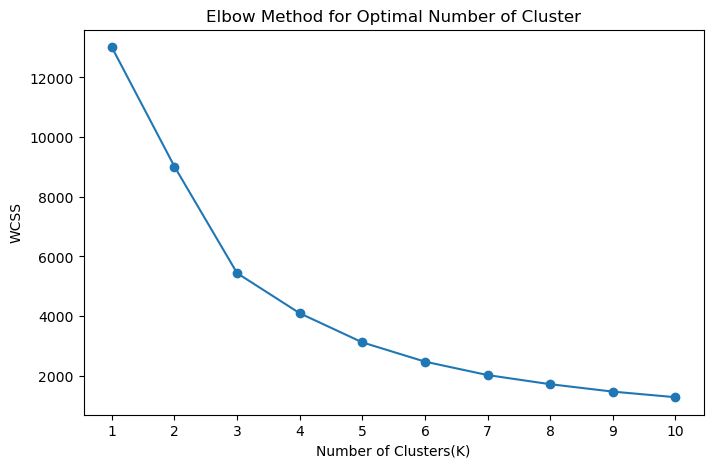

In [31]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow Method to find optimal K
# Calculate WCSS for different values of K
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Display WCSS values
print("WCSS Values:")
for k, value in zip(range(1, 11), wcss):
    print(f"K = {k}: WCSS = {value:.2f}")

# Plot Elbow Curve
plt.figure(figsize = (8, 5))
plt.plot(range(1, 11), wcss, marker = 'o')
plt.title('Elbow Method for Optimal Number of Cluster')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()

In [32]:
# Apply K-Means using the optimal number of clusters
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary  Cluster
0       12346      326          1  77183.60        0
1       12347        2          7   4310.00        1
2       12348       75          4   1797.24        1
3       12349       19          1   1757.55        1
4       12350      310          1    334.40        0


In [33]:
print(rfm['Cluster'].value_counts().sort_index())

Cluster
0    1082
1    3230
2      26
Name: count, dtype: int64


## Customer Segmentation with K-Means
The K-Means clustering algorithm was used to segment customers based on their purchasing behaviour captured through the RFM features.
## Optimal Cluster Selection
The Elbow Method was applied by calculating the Within-Cluster Sum of Squares (WCSS) for different values of K. The Elbow Curve was analyzed to identify the point where adding additional clusters provided diminishing improvements in within-cluster variation.
- Based on the Elbow Method, K = 3 was selected as the optimal number of clusters for the customer segmentation analysis.
## K-Means Clustering
K-Means clustering was applied with K = 3. Each customer was assigned to one of three clusters based on Recency, Frequency, and Monetary values.
### Sample Output
| CustomerID | Recency | Frequency | Monetary  | Cluster |
|------------|---------|-----------|-----------|---------|
| 12346      | 326     | 1         | 77183.60  | 0       |
| 12347      | 2       | 7         | 4310.00   | 1       |
| 12348      | 75      | 4         | 1797.24   | 1       |
| 12349      | 19      | 1         | 1757.55   | 1       |
| 12350      | 310     | 1         | 334.40    | 0       |
## Cluster Profiling
- **Cluster 0** – High Value but Inactive: Very high spend, long recency, low frequency → re‑engagement needed.  
- **Cluster 1** – Active & Loyal: Recent purchases, higher frequency, moderate spend → maintain engagement, upsell.  
- **Cluster 2** – Occasional / Low Value: Moderate recency, low frequency, low spend → encourage repeat purchases.  
## Conclusion
The clustering with **3 segments** provides actionable insights: retain loyal buyers, re‑engage high‑value inactive customers, and convert occasional buyers into repeat customers.

# Scatter Plot

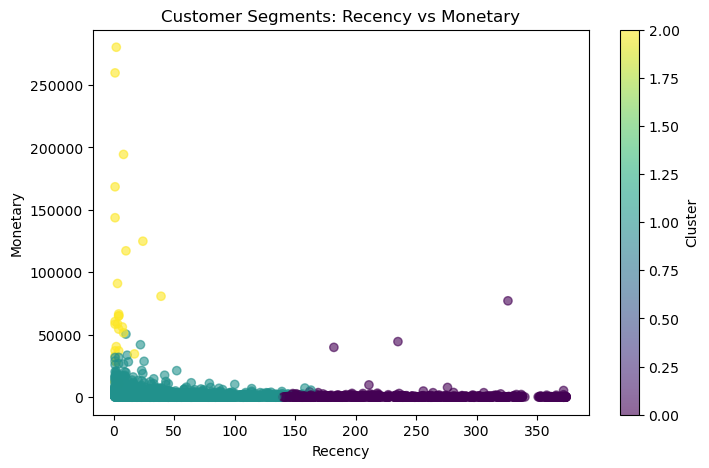

In [34]:
# Scatter Plot: Recency vs Monetary

plt.figure(figsize = (8, 5))
plt.scatter(rfm['Recency'], rfm['Monetary'], c = rfm['Cluster'], cmap = 'viridis', alpha = 0.6)
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segments: Recency vs Monetary')
plt.colorbar(label = 'Cluster')
plt.show()

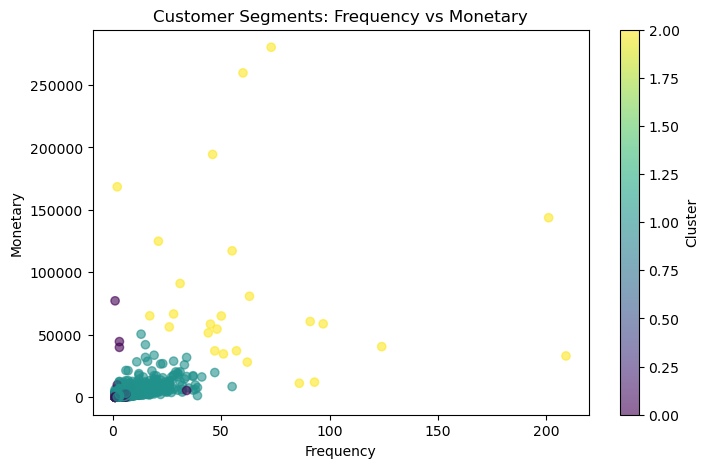

In [35]:
# Scatter Plot: Frequency vs Monetary

plt.figure(figsize = (8, 5))
plt.scatter(rfm['Frequency'], rfm['Monetary'], c = rfm['Cluster'], cmap = 'viridis', alpha = 0.6)
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segments: Frequency vs Monetary')
plt.colorbar(label = 'Cluster')
plt.show()

## Cluster Visualisation
To validate the clustering results, scatter plots were created using different feature combinations:
- **Recency vs Monetary:** Shows that customers with recent purchases (low recency) tend to have higher monetary values, while inactive customers (high recency) contribute less revenue.  
- **Frequency vs Monetary:** Highlights spending behaviour relative to purchase frequency. Loyal customers with higher frequency also show higher monetary contribution, while occasional buyers cluster around low frequency and low spend.

### Outcome
The visualisations clearly separate the three clusters, confirming meaningful segmentation:
- **Cluster 0:** High-value but inactive customers.  
- **Cluster 1:** Active and loyal customers.  
- **Cluster 2:** Occasional/low-value customers.  

# Cluster Profiling

In [37]:
# Calculate mean RFM value for each cluster

cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_profile)

         Recency  Frequency  Monetary
Cluster                              
0         247.11       1.58    629.66
1          41.45       4.67   1849.67
2           6.04      66.42  85826.08


In [38]:
# Add number of customers in each cluster
cluster_profile['Customer_Count'] = rfm['Cluster'].value_counts().sort_index()

print(cluster_profile)

         Recency  Frequency  Monetary  Customer_Count
Cluster                                              
0         247.11       1.58    629.66            1082
1          41.45       4.67   1849.67            3230
2           6.04      66.42  85826.08              26


In [39]:
# Calculate mean RFM values per cluster
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

print(cluster_profile)

# Optional: add customer type labels
def label_cluster(row):
    if row['Monetary'] > 10000 and row['Recency'] > 200:
        return "High Value but Inactive"
    elif row['Frequency'] >= 4 and row['Recency'] < 50:
        return "Active & Loyal"
    else:
        return "Occasional / Low Value"

# Apply labels
cluster_profile['Customer_Type'] = cluster_profile.apply(label_cluster, axis=1)

print(cluster_profile)


         Recency  Frequency  Monetary
Cluster                              
0         247.11       1.58    629.66
1          41.45       4.67   1849.67
2           6.04      66.42  85826.08
         Recency  Frequency  Monetary           Customer_Type
Cluster                                                      
0         247.11       1.58    629.66  Occasional / Low Value
1          41.45       4.67   1849.67          Active & Loyal
2           6.04      66.42  85826.08          Active & Loyal


## Cluster Profiling
The mean RFM values and customer counts for each cluster are as follows:

| Cluster | Recency (Mean) | Frequency (Mean) | Monetary (Mean) | Customer Count | Customer Type              |
|---------|----------------|------------------|-----------------|----------------|----------------------------|
| 0       | 247.11         | 1.58             | 629.66          | 1082           | High-value but inactive    |
| 1       | 41.45          | 4.67             | 1849.67         | 3230           | Active & loyal             |
| 2       | 6.04           | 66.42            | 85826.08        | 26             | Very high-value & frequent |

## Insights
- **Cluster 0 – High-value but inactive:** Customers with long recency, low frequency, and low spend. → Re‑engagement needed.  
- **Cluster 1 – Active & loyal:** Recent buyers with moderate frequency and spend. → Maintain engagement, upsell.  
- **Cluster 2 – Very high-value & frequent:** Small group of elite customers with extremely high spend and frequency. → VIP programs, personalized offers.  

## Conclusion
The profiling confirms three distinct customer segments, enabling targeted marketing strategies:  
- Re‑engage inactive high-value customers,  
- Nurture loyal buyers,  
- Prioritize elite high-value frequent customers.

# Bar Chart

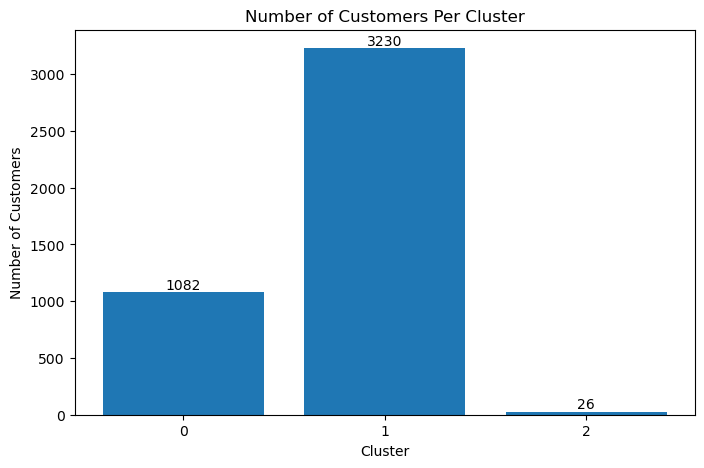

In [44]:
# Bar Chart: Number of customers of clusters

cluster_counts = rfm['Cluster'].value_counts().sort_index()
plt.figure(figsize = (8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title('Number of Customers Per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

# Displays value on top of  bars
for i, value in enumerate(cluster_counts.values):
    plt.text(i, value, str(value), ha = 'center', va = 'bottom')

plt.show()

## Cluster Distribution

A bar chart was used to visualize the distribution of customers across the three identified clusters.

- The visualization shows that **Cluster 1 represents the largest customer segment**, 
- While **Cluster 0** contains a smaller but substantial group of customers.
- **Cluster 2 is a relatively small segment**, indicating a distinct group of highly valuable customers identified through the RFM-based clustering analysis.

This distribution provides a clear overview of the size of each customer segment and supports further segment-specific marketing analysis.

# Marketing Insights and Recommendations

The customer segments identified through RFM-based K-Means clustering can be targeted with different marketing strategies based on their purchasing behaviour.

### Cluster 0 — At-Risk / Low-Engagement Customers

These customers have high recency, low purchase frequency, and relatively low monetary value, indicating declining engagement.

**Recommended Action:**  
- Run targeted re-engagement campaigns using personalized product recommendations, 
- limited-time discounts, and special offers to encourage customers to return and make repeat purchases.

### Cluster 1 — Regular / Active Customers

This is the largest segment, with relatively recent activity and moderate purchase frequency and monetary value.

**Recommended Action:**  
- Strengthen customer loyalty through loyalty programs, personalized recommendations, cross-selling, and relevant promotional offers.
- The goal should be to increase purchase frequency and gradually move these customers toward higher-value segments.

### Cluster 2 — High-Value / VIP Customers

These customers show very recent activity, exceptionally high purchase frequency, and significantly higher monetary value, making them the most valuable segment.

**Recommended Action:**  
- Prioritize retention by providing VIP benefits, exclusive offers, early access to products, and personalized experiences. 
- The focus should be on maintaining long-term relationships rather than relying on broad discounts.

### Overall Insight
The segmentation shows that different customer groups require different marketing approaches. 
- At-risk customers should be targeted for re-engagement,
- Regular customers should be developed through loyalty and value-building strategies, and
- High-value customers should be prioritized for retention and exclusive experiences.
- This customer-specific approach can help improve engagement, retention, and overall customer value.